# Global problem with internal variables and sub-Newton: Norton creep

The same small-strain Norton model is used twice: first as a strain-controlled plane-strain material point via `dae.TimeSteppingManager`, then as a `SimState` finite element problem with a rectangular excavation in an initially lithostatic salt block.

[Download this notebook](https://github.com/BodeTobias/AutoPDEx/tree/main/docs/notebooks/norton_creep.ipynb)

In [6]:
from functools import partial
from pathlib import Path

import jax
import jax.numpy as jnp
import meshio
import numpy as np

from autopdex import SimState, dae, spaces
from autopdex.models import km_tools as km

jax.config.update("jax_enable_x64", True)


## Material model

Units are MPa, m and days. Plane strain is embedded in the compact Kelvin-Mandel vector `[xx, yy, zz, sqrt(2) xy]`:

$$
\boldsymbol\varepsilon =
\left[\varepsilon_{xx},\varepsilon_{yy},\varepsilon_{zz},\sqrt{2}\,\varepsilon_{xy}\right]^T
$$

All dot products below are Kelvin-Mandel products and therefore represent tensor contractions. With elastic strain

$$
\boldsymbol\varepsilon_\mathrm{e}
= \boldsymbol\varepsilon - \boldsymbol\varepsilon_\mathrm{cr},
$$

the elastic strain energy density and stress are

$$
\psi(\boldsymbol\varepsilon_\mathrm{e})
= \mu\,\boldsymbol\varepsilon_\mathrm{e}\cdot\boldsymbol\varepsilon_\mathrm{e}
+ \frac{1}{2}\lambda\,\mathrm{tr}(\boldsymbol\varepsilon_\mathrm{e})^2,
\qquad
\boldsymbol\sigma
= \frac{\partial \psi}{\partial \boldsymbol\varepsilon_\mathrm{e}}
+ \boldsymbol\sigma_0.
$$

The deviatoric and equivalent stresses are

$$
\boldsymbol s = \mathrm{dev}(\boldsymbol\sigma),
\qquad
\sigma_\mathrm{eq}
= \sqrt{\frac{3}{2}\,\boldsymbol s\cdot\boldsymbol s}.
$$

The two-term Norton creep law is integrated locally as

$$
\dot{\varepsilon}_\mathrm{cr,eq}
= A_1\left(\frac{\sigma_\mathrm{eq}}{\sigma_\mathrm{ref}}\right)^{n_1}
+ A_2\left(\frac{\sigma_\mathrm{eq}}{\sigma_\mathrm{ref}}\right)^{n_2},
\qquad
\dot{\boldsymbol\varepsilon}_\mathrm{cr}
= \dot{\varepsilon}_\mathrm{cr,eq}\,\frac{3}{2}\,\frac{\boldsymbol s}{\sigma_\mathrm{eq}}.
$$

In [7]:
E = 25_000.0
nu = 0.25
lam = E * nu / ((1.0 + nu) * (1.0 - 2.0 * nu))
mu = E / (2.0 * (1.0 + nu))

sigma_ref = 1.0
A1, n1 = 1.0e-7, 1.0
A2, n2 = 1.0e-10, 5.0

zero4 = jnp.zeros(4)

def strain_energy(eps_e):
    return mu * (eps_e @ eps_e) + 0.5 * lam * km.trace(eps_e) ** 2

def total_stress(eps, eps_cr, sigma_offset=zero4):
    return jax.jacrev(strain_energy)(eps - eps_cr) + sigma_offset

def equivalent_stress(sig):
    s = km.dev(sig)
    return jnp.sqrt(1.5 * (s @ s) + 1.0e-30)

def norton_creep(q_fun, t, settings):
    q, q_t = jax.jvp(q_fun, (t,), (1.0,))
    sig = total_stress(settings["eps"], q["eps_cr"], settings["sigma_offset"])
    s = km.dev(sig)
    sig_eq = equivalent_stress(sig)
    eq_rate = A1 * (sig_eq / sigma_ref) ** n1 + A2 * (sig_eq / sigma_ref) ** n2
    return q_t["eps_cr"] - eq_rate * 1.5 * s / sig_eq

## 1. Strain-controlled material point

The material point uses the prescribed compressive strain

$$
\boldsymbol\varepsilon(t)
= \left[-6\cdot 10^{-4}\min\left(\frac{t}{20\,\mathrm d},1\right),0,0,0\right]^T,
\qquad
\boldsymbol\sigma_0 = \boldsymbol 0,
\qquad
\boldsymbol\varepsilon_\mathrm{cr}(0)=\boldsymbol 0.
$$


In [ ]:
def strain_control(t):
    eps_xx = -6.0e-4 * jnp.minimum(t / 20.0, 1.0)
    return jnp.asarray([eps_xx, 0.0, 0.0, 0.0])

def material_point_model(q_fun, t, settings):
    return norton_creep(q_fun, t, {"eps": strain_control(t), "sigma_offset": zero4})

def material_point_output(q_fun, t, settings):
    q = q_fun(t)
    eps = strain_control(t)
    sig = total_stress(eps, q["eps_cr"])
    return {
        "eps_xx": eps[0],
        "eps_cr_eq": jnp.sqrt(2.0 / 3.0 * (q["eps_cr"] @ q["eps_cr"])),
        "sig_xx": sig[0],
        "sig_eq": equivalent_stress(sig),
    }

local_manager = dae.TimeSteppingManager(
    {
        "dae": material_point_model,
        "time integrators": {"eps_cr": dae.BackwardEuler()},
        "verbose": 0,
    },
    root_solver=partial(dae.newton_solver, atol=1e-13, rtol=1e-11),
    save_policy=dae.SaveAllPolicy(),
    postprocessing_fun=material_point_output,
)

result = local_manager.run({"eps_cr": zero4}, dt0=2.0, t_final=120.0, num_time_steps=60)

Progress: 3%, Time: 4.00e+00, dt: 2.00e+00, iterations: 1
Progress: 8%, Time: 1.00e+01, dt: 2.00e+00, iterations: 2
Progress: 13%, Time: 1.60e+01, dt: 2.00e+00, iterations: 2
Progress: 18%, Time: 2.20e+01, dt: 2.00e+00, iterations: 3
Progress: 23%, Time: 2.80e+01, dt: 2.00e+00, iterations: 2
Progress: 28%, Time: 3.40e+01, dt: 2.00e+00, iterations: 2
Progress: 33%, Time: 4.00e+01, dt: 2.00e+00, iterations: 2
Progress: 38%, Time: 4.60e+01, dt: 2.00e+00, iterations: 2
Progress: 43%, Time: 5.20e+01, dt: 2.00e+00, iterations: 2
Progress: 48%, Time: 5.80e+01, dt: 2.00e+00, iterations: 2
Progress: 53%, Time: 6.40e+01, dt: 2.00e+00, iterations: 2
Progress: 58%, Time: 7.00e+01, dt: 2.00e+00, iterations: 2
Progress: 63%, Time: 7.60e+01, dt: 2.00e+00, iterations: 2
Progress: 68%, Time: 8.20e+01, dt: 2.00e+00, iterations: 2
Progress: 73%, Time: 8.80e+01, dt: 2.00e+00, iterations: 2
Progress: 78%, Time: 9.40e+01, dt: 2.00e+00, iterations: 2
Progress: 83%, Time: 1.00e+02, dt: 2.00e+00, iterations: 2

Visualization

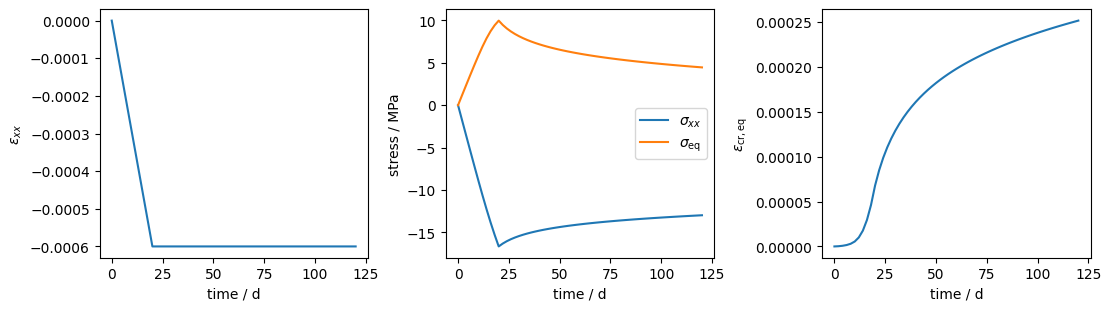

In [ ]:
hist = result.history
valid = np.isfinite(np.asarray(hist.t))
t = np.asarray(hist.t)[valid]
user = {key: np.asarray(value)[valid] for key, value in hist.user.items()}

import matplotlib.pyplot as plt
fig, ax = plt.subplots(1, 3, figsize=(11, 3), constrained_layout=True)
ax[0].plot(t,user["eps_xx"])
ax[0].set_xlabel("time / d")
ax[0].set_ylabel(r"$\epsilon_{xx}$")

ax[1].plot(t, user["sig_xx"], label=r"$\sigma_{xx}$")
ax[1].plot(t, user["sig_eq"], label=r"$\sigma_\mathrm{eq}$")
ax[1].set_xlabel("time / d")
ax[1].set_ylabel("stress / MPa")
ax[1].legend()

ax[2].plot(t, user["eps_cr_eq"])
ax[2].set_xlabel("time / d")
ax[2].set_ylabel(r"$\epsilon_\mathrm{cr,eq}$")

plt.show()

## 2. SimState excavation problem

The block is loaded by self weight and a lithostatic far-field traction on the top boundary. With $y$ measured upward from the block center,

$$
p_\mathrm{litho}(\boldsymbol x)
= \gamma\left(d_\mathrm c-y\right),
\qquad
\gamma = \frac{\rho_\mathrm{salt}g}{10^6},
$$

and the stress offset used by the constitutive update is

$$
\boldsymbol\sigma_0
= \left[-p_\mathrm{litho},-p_\mathrm{litho},-p_\mathrm{litho},0\right]^T.
$$

The plane-strain kinematics used in `weak_form` are

$$
\boldsymbol\varepsilon(\boldsymbol u)
= \left[u_{x,x},u_{y,y},0,\frac{u_{x,y}+u_{y,x}}{\sqrt{2}}\right]^T.
$$

Together with the separately added Neumann contribution, the weak form is

$$
\int_\Omega \boldsymbol\sigma : \boldsymbol\varepsilon(\boldsymbol v)\,\mathrm d\Omega
- \int_\Omega \boldsymbol b\cdot\boldsymbol v\,\mathrm d\Omega
- \int_{\Gamma_t}\bar{\boldsymbol t}\cdot\boldsymbol v\,\mathrm d\Gamma
=0,
\qquad
\boldsymbol b = \left[0,-\gamma\right]^T.
$$

The strong displacement boundary conditions and the weak top load are

$$
u_x=0 \quad \text{on} \quad x=\pm\frac{W}{2},
\qquad
u_y=0 \quad \text{on} \quad y=-\frac{H}{2},
$$

$$
\bar{\boldsymbol t}=\left[0,-p_\mathrm{litho}\right]^T
\quad \text{on} \quad y=\frac{H}{2}.
$$

The excavation boundary remains traction-free because no inhomogeneous weak boundary load is added there.


In [ ]:
mesh_path = Path("meshes/norton_creep_rectangular_hole.vtu")
mesh = meshio.read(mesh_path)

width, height = 80.0, 80.0
rho_salt = 2160.0
gravity = 9.81
depth_at_center = 750.0
unit_weight = rho_salt * gravity / 1.0e6  # MPa / m

def lithostatic_pressure(x):
    return unit_weight * (depth_at_center - x[1])

In [ ]:
def weak_form(ctx: SimState.ModelContext):
    x = ctx.trial_ansatz["physical coor"](ctx.x_int)
    p = lithostatic_pressure(x)
    sigma0 = jnp.asarray([-p, -p, -p, 0.0])
    grad_u = jax.jacfwd(ctx.trial_ansatz["displacement"])(ctx.x_int, ctx.t)
    eps = km.pack_z_shear_zero(grad_u)

    if ctx.mode in ("weak form", "internal variables"):
        new_int_vars = ctx.solve_local("creep", inputs={"eps": eps, "sigma_offset": sigma0})

        if ctx.mode == "internal variables":
            return new_int_vars

        sig = total_stress(eps, new_int_vars["eps_cr"], sigma0)
        grad_v = jax.jacfwd(ctx.test_ansatz["displacement"])(ctx.x_int)
        v = ctx.test_ansatz["displacement"](ctx.x_int)
        body_force = jnp.asarray([0.0, -unit_weight])
        return sig @ km.pack_z_shear_zero(grad_v) - body_force @ v

    if ctx.mode == "output":
        u = ctx.trial_ansatz["displacement"](ctx.x_int, ctx.t)
        sig = total_stress(eps, ctx.internal_vars["eps_cr"], sigma0)
        return {
            "u": u,
            "eps_cr": ctx.internal_vars["eps_cr"],
            "sig_eq": equivalent_stress(sig),
            "sig_xx": sig[0],
            "sig_yy": sig[1],
            "sig_zz": sig[2],
            "sig_xy": sig[3] / jnp.sqrt(2.0),
        }


In [ ]:
sim = SimState({
    "displacement": spaces.H1(order=2, dim=2, field_dimension=2),
    "eps_cr": spaces.InternalVariable(field_dimension=4),
})
sim.import_mesh(mesh)
sim.add_temporal_discretization({
    "displacement": dae.NoTimeDerivative(),
    "eps_cr": dae.BackwardEuler(),
})
sim.add_local_subsystem(
    "creep",
    norton_creep,
    fields=("eps_cr",),
    root_solver=partial(dae.newton_solver, atol=1e-14, rtol=1e-12),
)
sim.add_model("__all__", "weak form", weak_form, internal_variables=("eps_cr",))

sim.add_strong_bc("displacement", lambda x: jnp.isclose(x[0], -0.5 * width), lambda x, t: 0.0, index=0)
sim.add_strong_bc("displacement", lambda x: jnp.isclose(x[0], 0.5 * width), lambda x, t: 0.0, index=0)
sim.add_strong_bc("displacement", lambda x: jnp.isclose(x[1], -0.5 * height), lambda x, t: 0.0, index=1)
sim.add_weak_bc("displacement", lambda x: jnp.isclose(x[1], 0.5 * height), lambda x, t: jnp.asarray([0.0, -lithostatic_pressure(x)]))

sim.set_postprocessing_policy(
    dae.SaveEquidistantPolicy(num_points=30),
    result_folder_name="norton_creep.res",
)
sim.set_step_size_controller(dae.RootIterationController(target_niters=8, max_step_size=50.0))

sim.initialize(verbose=1)
sim.set_root_solver(partial(dae.newton_solver, atol=1e-9, rtol=1e-7))
sim.prepare()

sim = sim.run(dt0=2.0, time_span=3000.0, num_time_steps=1000)
print(f"accepted steps = {int(sim.num_accepted)}, final time = {float(sim.settings['current time']):.1f} d")


Linear solver: Pardiso(lu); 32 threads.
Iteration 1, Residual norm: 0.8703147090298352
Iteration 2, Residual norm: 0.11392621541074148
Iteration 3, Residual norm: 0.002784154047653472
Iteration 4, Residual norm: 2.429917191604873e-06
Iteration 5, Residual norm: 1.323047195918442e-08
 
Iteration 1, Residual norm: 0.07046536440792059
Iteration 2, Residual norm: 0.0015103900747676033
Iteration 3, Residual norm: 1.0171819275356981e-06
Iteration 4, Residual norm: 1.4655309009388022e-08
 
Iteration 1, Residual norm: 0.06200617880926995
Iteration 2, Residual norm: 0.0014424988693897613
Iteration 3, Residual norm: 1.0741481588443244e-06
Iteration 4, Residual norm: 1.8146856555779567e-08
 
Iteration 1, Residual norm: 0.06117959594928221
Iteration 2, Residual norm: 0.0016102375058392748
Iteration 3, Residual norm: 1.461409465188693e-06
Iteration 4, Residual norm: 2.304596826187511e-08
 
Iteration 1, Residual norm: 0.06419768943026878
Iteration 2, Residual norm: 0.0019512776345168414
Iteration 3,

### Final deformation state: zoom to the excavation

<img src="../_static/norton_creep.png" width=600>